<a href="https://colab.research.google.com/github/bonheurjulord-ui/Projet-3-Pipeline-complet-de-Machine-Learning-pour-la-pr-diction-des-prix-immobiliers./blob/main/Projet_3_Pipeline_complet_de_Machine_Learning_pour_la_pr%C3%A9diction_des_prix_immobiliers_(analyse%2C_pr%C3%A9paration_et_mod%C3%A9lisation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projet:

Ce que vous visez:

Démontrez votre capacité à évaluer un modèle d'apprentissage automatique à l'aide d'une stratégie de validation (division train/test ou validation croisée) et à interpréter ses indicateurs de performance.

Instructions

Vous utiliserez un jeu de données de classification (par exemple, Iris , Titanic ou tout autre jeu de données disponible) pour :

Charger et préparer les données

Importer un jeu de données (par exemple, depuis sklearn.datasets ou seaborn)
Fonctionnalités distinctes et cible
Effectuez tout prétraitement de base (si nécessaire).
Diviser les données

Utilisez la fonction train_test_split() du package sklearn.model_selection.
Ratio suggéré : 80 % d’entraînement / 20 % de tests
Définir random_state=42 pour la reproductibilité
Entraîner un modèle

Utilisez un classificateur de votre choix (par exemple, KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression).
Ajuster le modèle aux données d'entraînement
Évaluer sur l'ensemble de test

Prédire les valeurs pour l'ensemble de test

Imprimer et interpréter : Score de précision, Matrice de confusio et(Facultatif) Rapport de classification (précision, rappel, score F1)

Utiliser la validation croisée

Appliquez cross_val_score() avec 5 plis sur l'ensemble des données.
Comparez les résultats de la validation croisée avec ceux obtenus par une seule division en ensembles d'entraînement et de test.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# packages for preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
# packages for buld model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
## package for make evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,roc_curve,auc

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
##Analyse et compréhension des données
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
##taille du dataframe
df.shape

(891, 12)

In [ ]:
##identification de valeur manquantes par colonnes
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
##resumé rapide du dataframme
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
## Séparation du dataset en dataset catégoriel et numérique afin de faire les imputations nécessaires

### Cas des variables catégorielles

df_cat = df.select_dtypes(include=['object'])

df_cat = df_cat.drop(['Name', 'Ticket'], axis=1)
df_cat.head()

,Sex,Cabin,Embarked
0,male,NaN,S
1,female,C85,C
2,female,NaN,S
3,female,C123,S
4,male,NaN,S


In [ ]:
## imputation des variables catégorielles
imputer_cat = SimpleImputer(strategy='most_frequent')

df_cat = pd.DataFrame(imputer_cat.fit_transform(df_cat), columns=df_cat.columns)
df_cat.isna().sum()

,0
Sex,0
Cabin,0
Embarked,0


In [ ]:
## Cas des variables numériques
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [ ]:
##imputation de valeurs manquantes
imputer_num = SimpleImputer(strategy='median')

df_num = pd.DataFrame(imputer_num.fit_transform(df_num), columns=df_num.columns)
df_num.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0


In [ ]:
## Fusion des données déja imputées
df_clean = pd.concat([df_cat, df_num], axis=1)

df_clean = df_clean.drop(['PassengerId'], axis=1)
df_clean.head()

,Sex,Cabin,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,male,B96 B98,S,0.0,3.0,22.0,1.0,0.0,7.2500
1,female,C85,C,1.0,1.0,38.0,1.0,0.0,71.2833
2,female,B96 B98,S,1.0,3.0,26.0,0.0,0.0,7.9250
3,female,C123,S,1.0,1.0,35.0,1.0,0.0,53.1000
4,male,B96 B98,S,0.0,3.0,35.0,0.0,0.0,8.0500


In [ ]:
##suppression de variables
df_clean = df_clean.drop(['Cabin'], axis=1)
df_clean.head()

,Sex,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,male,S,0.0,3.0,22.0,1.0,0.0,7.2500
1,female,C,1.0,1.0,38.0,1.0,0.0,71.2833
2,female,S,1.0,3.0,26.0,0.0,0.0,7.9250
3,female,S,1.0,1.0,35.0,1.0,0.0,53.1000
4,male,S,0.0,3.0,35.0,0.0,0.0,8.0500


In [ ]:
##Analyse focus sur la cible
###distribution de la variable cible
df_clean['Survived'].value_counts(normalize=True)

,proportion
Survived,
0.0,0.616162
1.0,0.383838


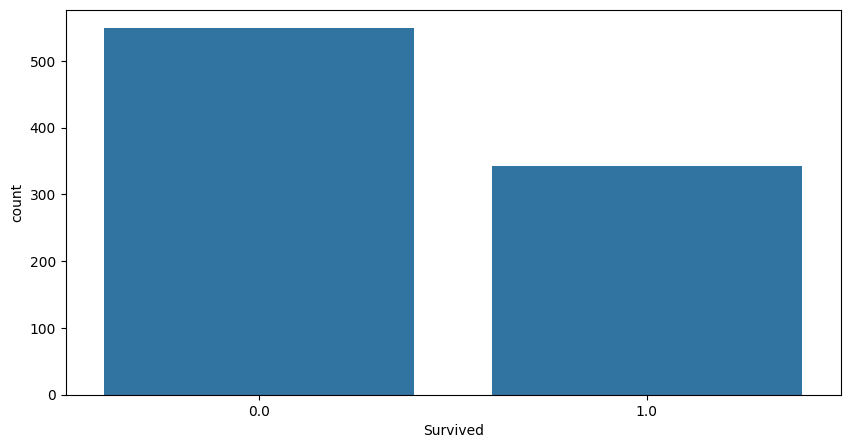

In [ ]:
## Visualisation de la variable
plt.figure(figsize=(10, 5))
sns.countplot(x='Survived', data=df_clean)
plt.show()

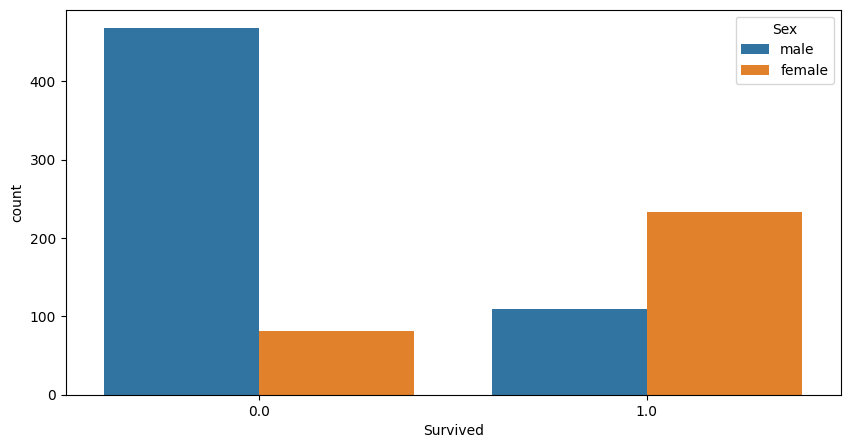

In [ ]:
##analyse visuelle de la survie selon le sexe
plt.figure(figsize=(10, 5))
sns.countplot(x='Survived', hue='Sex', data=df_clean)
plt.show()

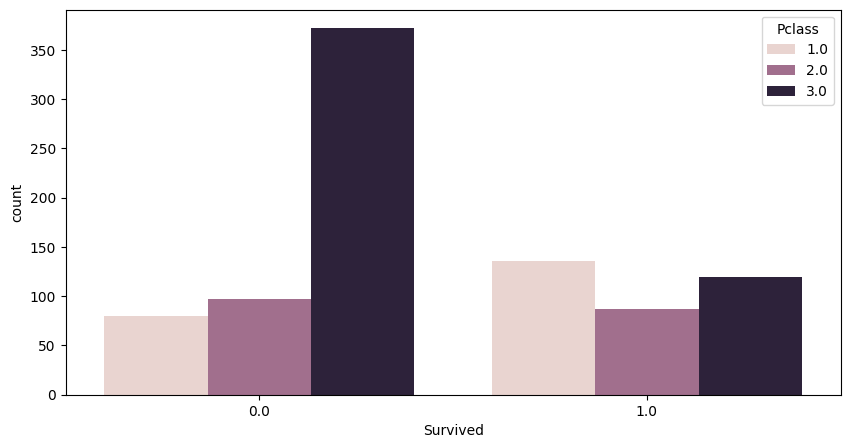

In [ ]:
##analyse de l'impact de la classe sociale sur la survie
plt.figure(figsize=(10, 5))
sns.countplot(x='Survived', hue='Pclass', data=df_clean)
plt.show()

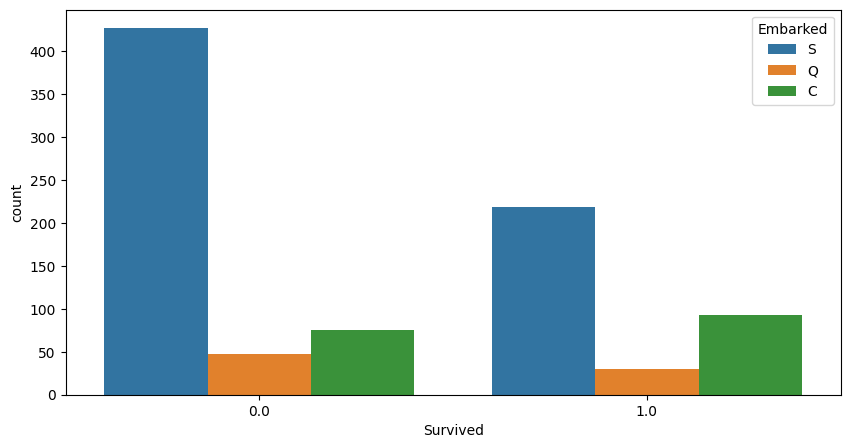

In [ ]:
##analyse l'effet du port d'embarquement sur la survie du titanic
plt.figure(figsize=(10, 5))
sns.countplot(x='Survived', hue='Embarked', data=df_clean)
plt.show()
#

Croisement entre la cible et l'âge des passagers. Comment la cible est catégorielle et l'âge continue, alors le boxplot est mieux indiqué pour analyser la relation entre les deux variables.

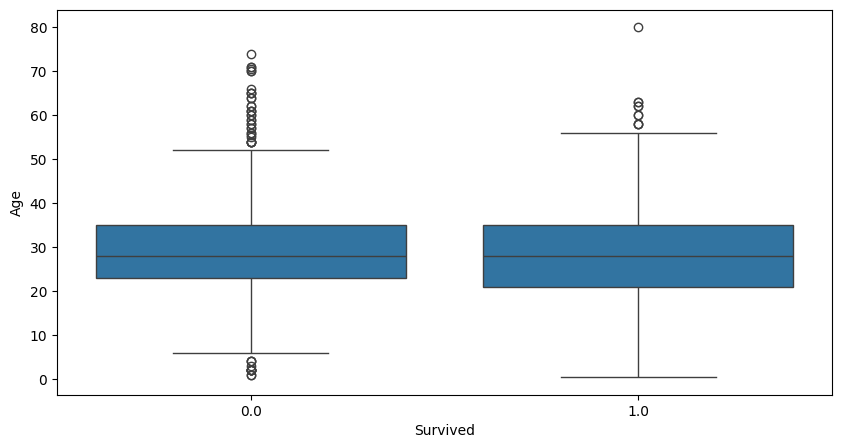

In [ ]:
##Croisement entre la cible et l'âge des passagers
plt.figure(figsize=(10, 5))
sns.boxplot(x='Survived', y='Age', data=df_clean)
plt.show()
#

ge contient des valeurs extrêmes. On fait une transformation logarithmique pour atténuer l'impact de ces valeurs sur nos estimations.

In [ ]:
##transformation des données
df_clean['Age'] = np.log1p(df_clean['Age'])
df_clean.head()

,Sex,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,male,S,0.0,3.0,3.135494,1.0,0.0,7.2500
1,female,C,1.0,1.0,3.663562,1.0,0.0,71.2833
2,female,S,1.0,3.0,3.295837,0.0,0.0,7.9250
3,female,S,1.0,1.0,3.583519,1.0,0.0,53.1000
4,male,S,0.0,3.0,3.583519,0.0,0.0,8.0500


In [ ]:
##analyse statistique descriptive de la variable age
stat = {
    'mean': df_clean['Age'].mean(),
    'median': df_clean['Age'].median(),
    'std': df_clean['Age'].std(),

}

stat

{'mean': np.float64(3.2804123726742906),
 'median': 3.367295829986474,
 'std': 0.6137838535289436}

In [ ]:
##transformation de la variable Fare
df_clean['Fare'] = np.log1p(df_clean['Fare'])
df_clean.head()

,Sex,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,male,S,0.0,3.0,3.135494,1.0,0.0,2.110213
1,female,C,1.0,1.0,3.663562,1.0,0.0,4.280593
2,female,S,1.0,3.0,3.295837,0.0,0.0,2.188856
3,female,S,1.0,1.0,3.583519,1.0,0.0,3.990834
4,male,S,0.0,3.0,3.583519,0.0,0.0,2.202765


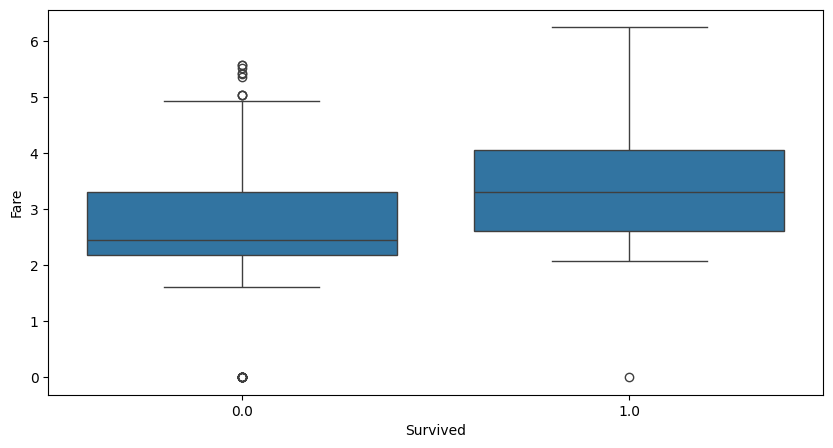

In [ ]:
##analyse de distribution + outlier + relation avec la survie
plt.figure(figsize=(10, 5))
sns.boxplot(x='Survived', y='Fare', data=df_clean)
plt.show()

II. Prétraitement des données

Mise à l'échelle d'une variable numérique (effet mesure)

. Encodage des variables non numériques (OneHotEncoder) : Une technique qui crée autant de nouvelle colonne que la variable à de modalité. Chaque nouvelle colonne est dichotomique traduisant si la modalité ciblée est retenue ou pas.

. Division de notre échantillon et données d'entraînement et données de test (80%, 20%)

In [ ]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

In [ ]:
# Encodage des variables catégorielles
encoder = OneHotEncoder()
df_enc = encoder.fit_transform(X[['Sex', 'Embarked']]).toarray()

df_enc = pd.DataFrame(df_enc, columns=encoder.get_feature_names_out(['Sex', 'Embarked']))
df_enc.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [ ]:
##Préparation du dataset pour le machine learning
X = X.drop(['Sex','Embarked'],axis=1)

X = pd.concat([X, df_enc], axis=1)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3.0,3.135494,1.0,0.0,2.110213,0.0,1.0,0.0,0.0,1.0
1,1.0,3.663562,1.0,0.0,4.280593,1.0,0.0,1.0,0.0,0.0
2,3.0,3.295837,0.0,0.0,2.188856,1.0,0.0,0.0,0.0,1.0
3,1.0,3.583519,1.0,0.0,3.990834,1.0,0.0,0.0,0.0,1.0
4,3.0,3.583519,0.0,0.0,2.202765,0.0,1.0,0.0,0.0,1.0


In [ ]:
## Scaling = Centrage et réduction des données
scaler = StandardScaler()

df_scale = scaler.fit_transform(X[['Age', 'Fare']])

df_scale = pd.DataFrame(df_scale, columns=scaler.get_feature_names_out(['Age', 'Fare']))
df_scale.head()

,Age,Fare
0,-0.236239,-0.879741
1,0.624592,1.361220
2,0.025144,-0.798540
3,0.494110,1.062038
4,0.494110,-0.784179


In [ ]:
##remplacement des variables numérique par leur version normalisée
X = X.drop(['Age','Fare'],axis=1)

X = pd.concat([X, df_scale], axis=1)
X.head()

,Pclass,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age,Fare
0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.236239,-0.879741
1,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.624592,1.361220
2,3.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.025144,-0.798540
3,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.494110,1.062038
4,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.494110,-0.784179


In [ ]:
## Split train and test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y)

III. **Modélisation et Évaluation**

Dans cette nous donnons à la machine la possibilité d'apprendre àpartir des données d'entraînement. On utilise différents modèles (Régression logistique, Arbre de décision, Forêt aléatoire...) pour ajuster nos données. Après la phase train, on juge la capacité du modèle à faire de bonnes prédictions (Evaluation)

In [ ]:
## Entrainement du modéle logistique avec nos données
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
## Evaluation du modele
y_pred_lr = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[99 11]
 [23 46]]
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85       110
         1.0       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



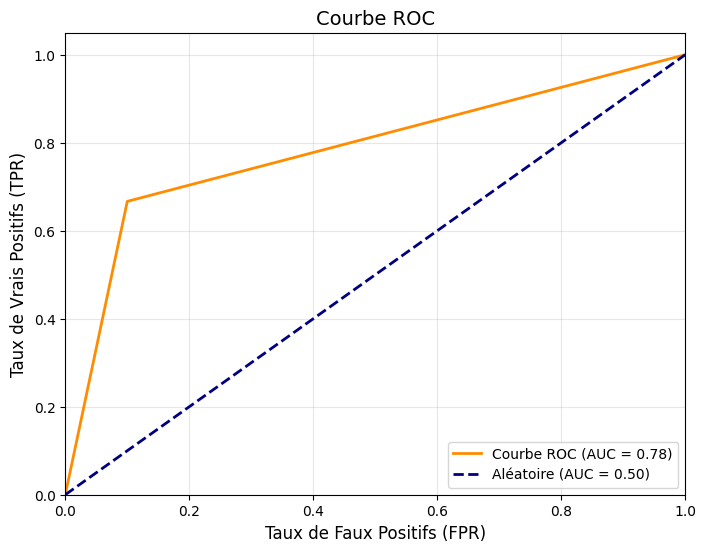

In [ ]:
# @title
# Courbe de ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
## Buld decision tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
## Evaluation
y_pred_dt = dt.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[95 15]
 [19 50]]
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.85       110
         1.0       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



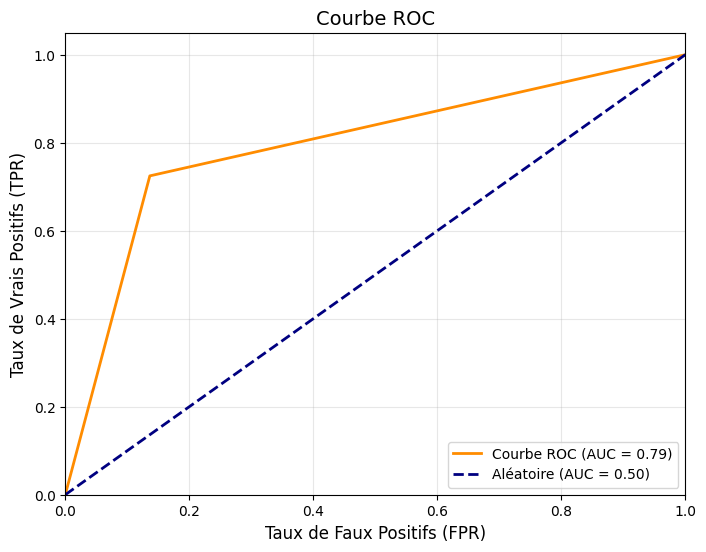

In [ ]:
# @title
# Courbe de ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_dt)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
## Buld Random Forest model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
## Evaluation
y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

[[98 12]
 [21 48]]
              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86       110
         1.0       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



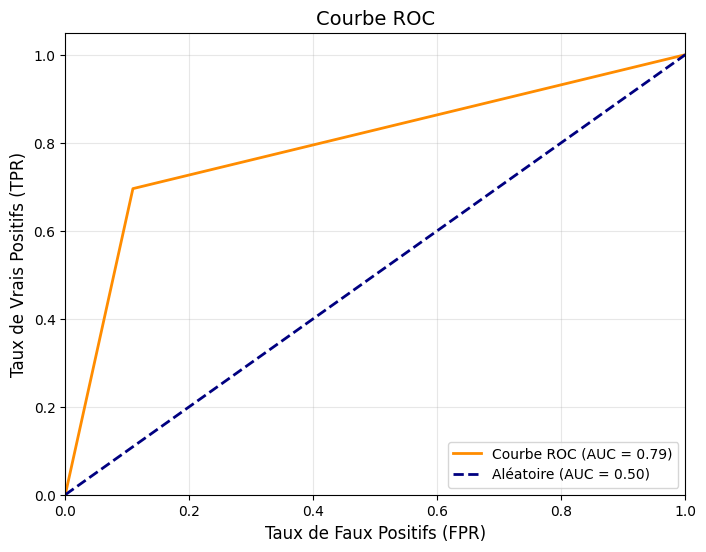

In [ ]:
# Courbe de ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

**Régression sur le dataset Boston Housing**

**Partie 2 - Régression**

Chargez un ensemble de données de régression (par exemple, Boston Housing ou des données synthétiques).
Former un modèle de régression (par exemple, régression linéaire ou régresseur d'arbre de décision).

Évaluez-le en utilisant :

- l'erreur absolue moyenne (MAE)
- Erreur quadratique moyenne (MSE)
- Erreur quadratique moyenne (RMSE)
- Score R²

Interprète :

- Que révéle les erreurs ?
- Votre modèle est-il sous-adapté ou suradapté ?

In [ ]:
# package nécessaire
## For exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## For Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

## For modeling
from sklearn.linear_model import LinearRegression
#from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## For Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/Housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Analyse et compréhension des données

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Nous notons des valeurs manquantes sur la variable total_bedrooms (207). Alors on va les imputer ces valeurs sur cette variable.

In [ ]:
imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


* Analysons la variable: la valeur médiane de la maison

In [ ]:
stat = {
    'mean': df['median_house_value'].mean(),
    'median': df['median_house_value'].median(),
    'std': df['median_house_value'].std(),

}

print(stat)

{'mean': np.float64(206855.81690891474), 'median': 179700.0, 'std': 115395.6158744132}


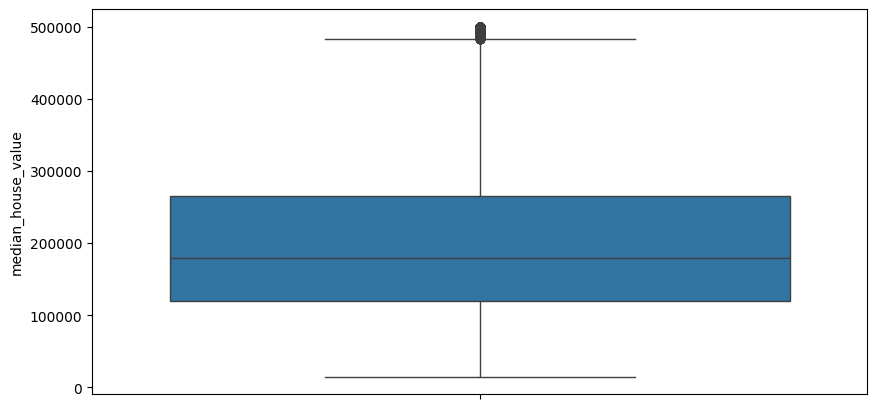

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(df['median_house_value'])
plt.show()

Nous notons la présence de valeurs extremes sur la cible. On va alors essayer de diminuer leur impact en faisant une transformation logarithmique.

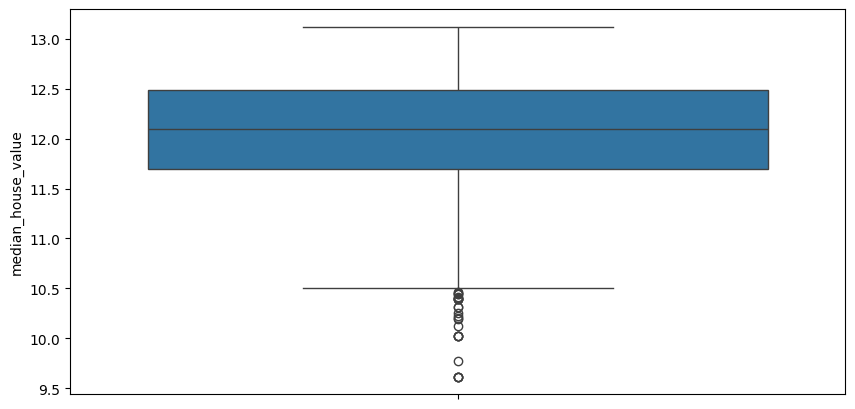

In [ ]:
# @title
df['median_house_value'] = np.log1p(df['median_house_value'])

plt.figure(figsize=(10, 5))
sns.boxplot(df['median_house_value'])
plt.show()

In [ ]:
# @title
stat1 = {
    'mean': df['median_house_value'].mean(),
    'median': df['median_house_value'].median(),
    'std': df['median_house_value'].std()

}

stat1

{'mean': np.float64(12.084890845009992),
 'median': 12.09904963758644,
 'std': 0.5691306068427149}

Analyse Bivariée: Analyser les relation entre la variable et les prédicteurs. L'util pairplot de seaborn nous permet de visualiser les relations paires entre tous les variables de notre dataset.

<Figure size 1000x500 with 0 Axes>

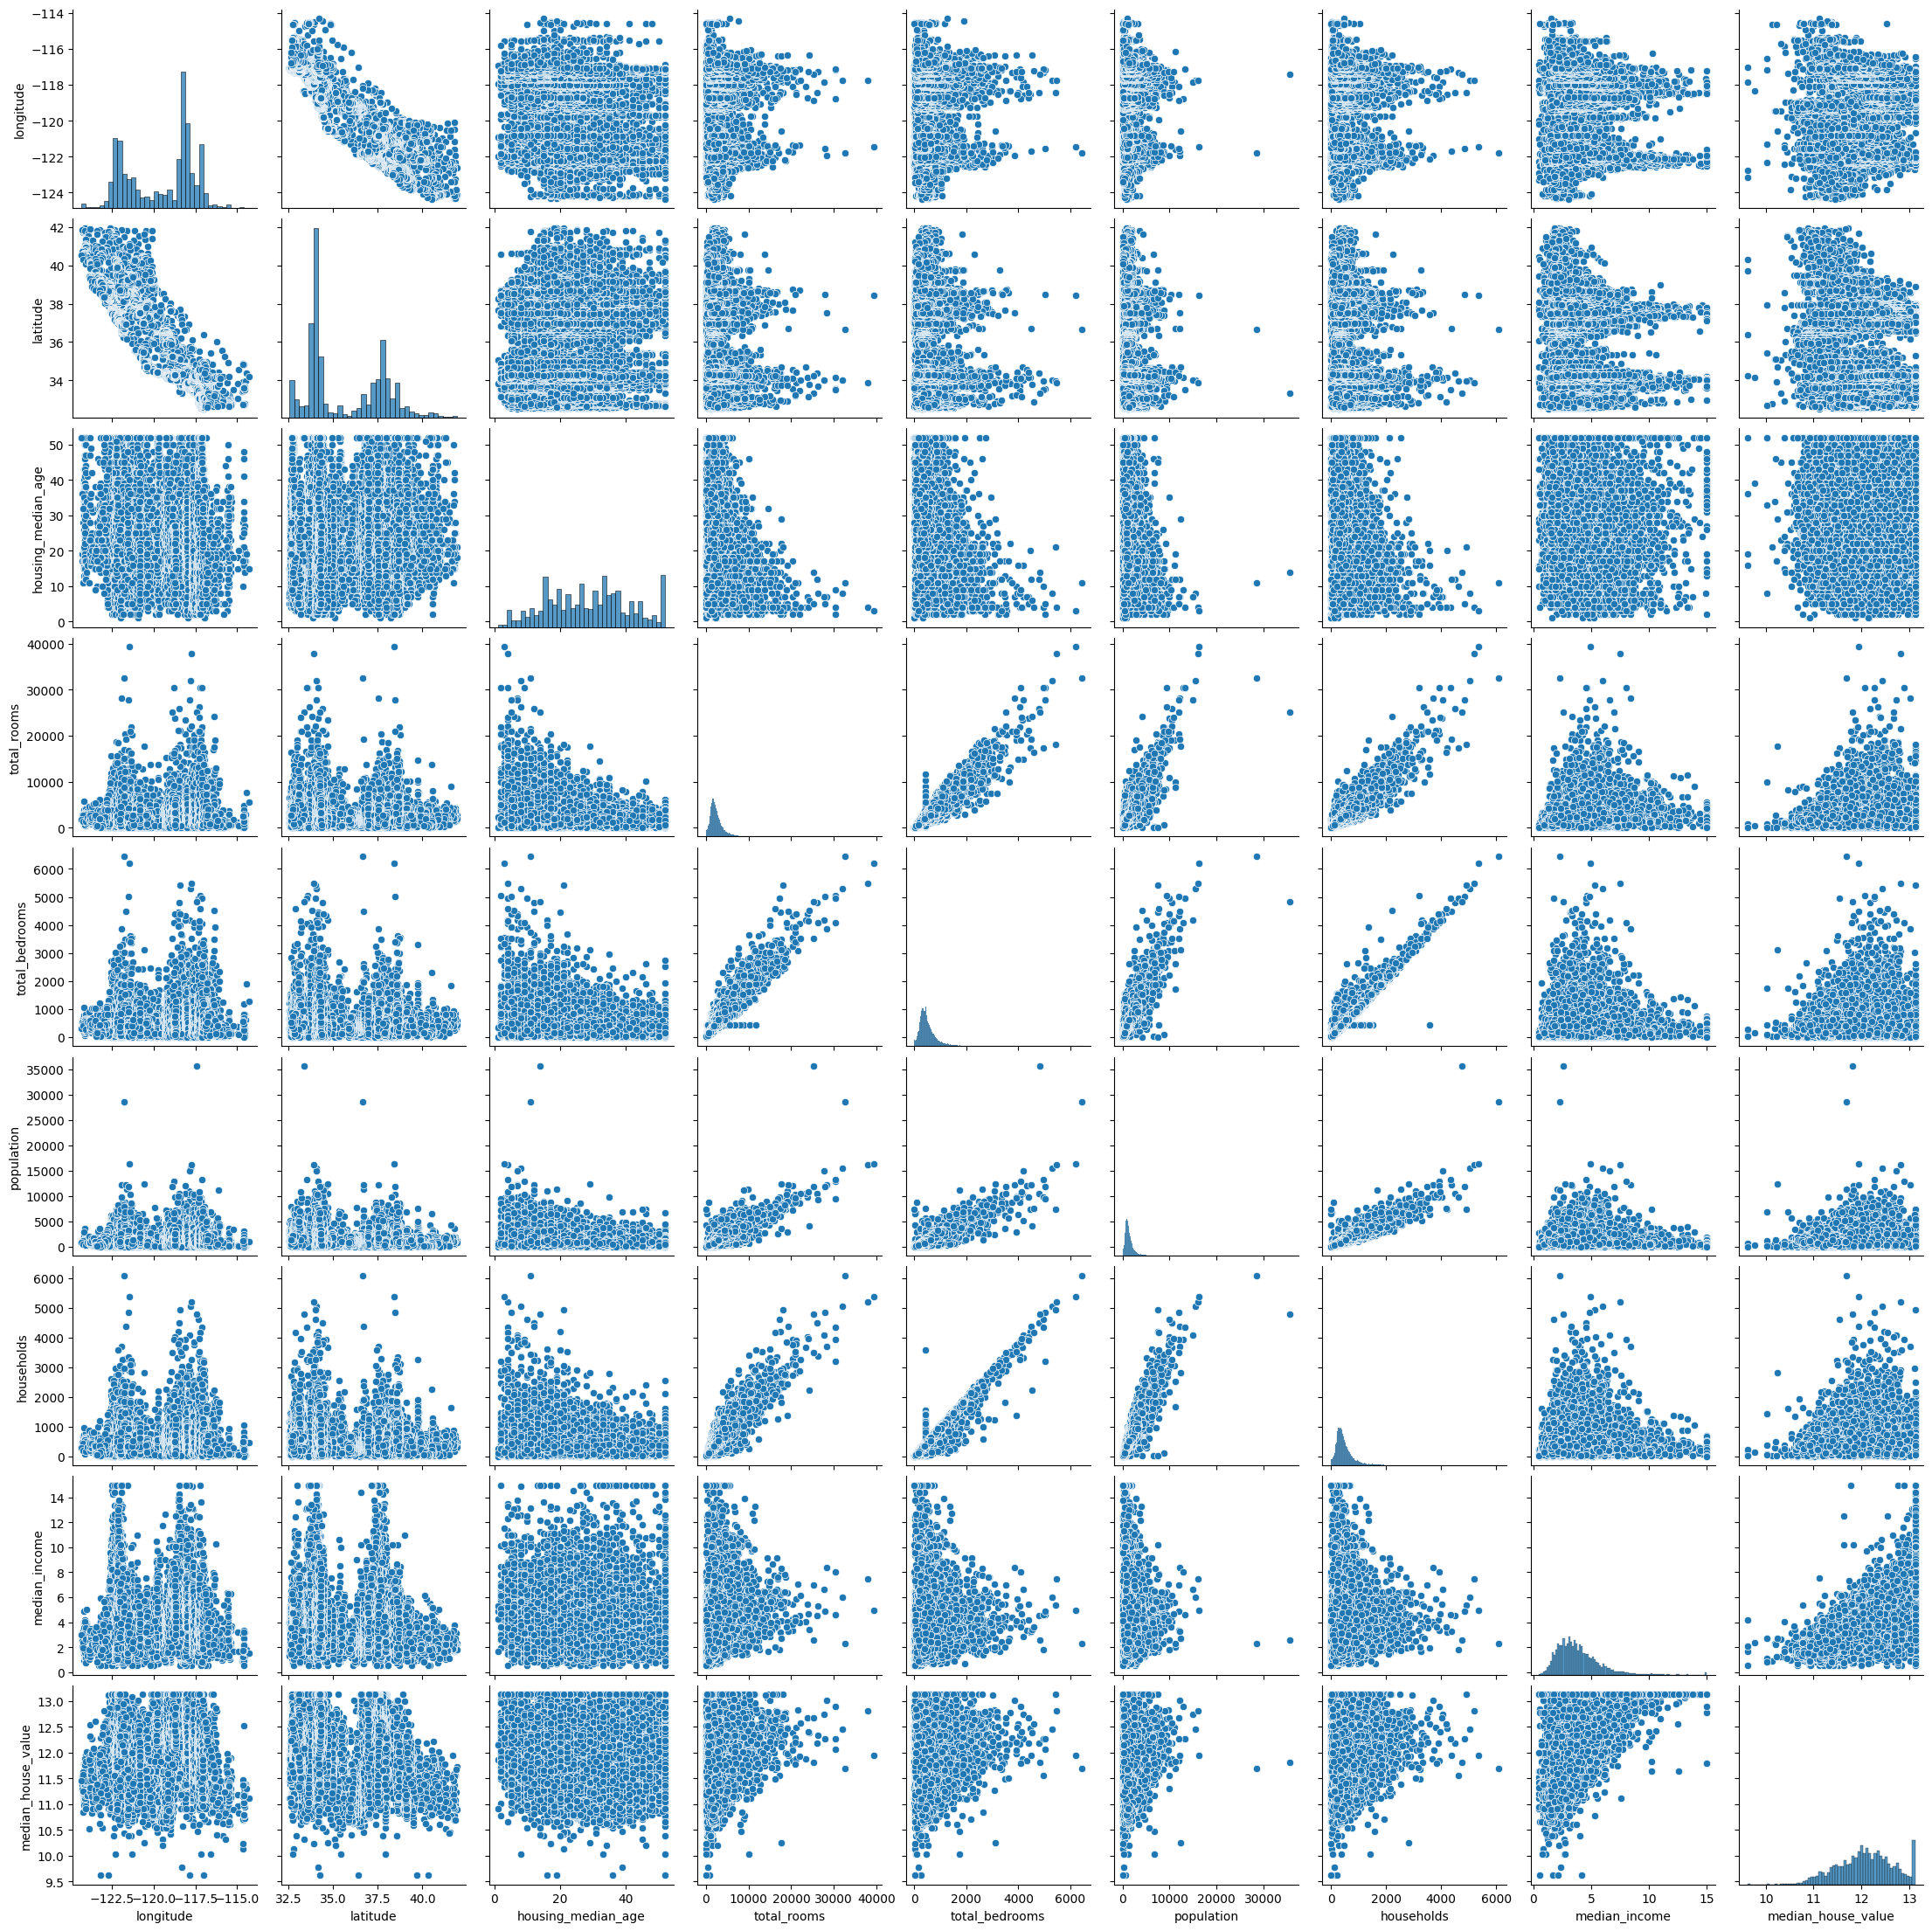

In [ ]:
## Analyse biavariée

plt.figure(figsize=(10, 5))
sns.pairplot(data = df)
plt.show()

La variable ocean proxility est la seule variable non numérique de notre échantillon. Donc à encoder. On va analyser d'abord cette variable pour comprendre sa distribution.

In [ ]:
## Analyse de la variable ocean_proximity

df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


Comme le revenu est une variable souvent distribué de facon asymétrique. Analyse la afin de detecter si elle présente des valeurs aberrantes ou pas.

In [ ]:
stat_rev = {
    'mean': df['median_income'].mean(),
    'median': df['median_income'].median(),
    'std': df['median_income'].std(),
    'min': df['median_income'].min(),
    'max': df['median_income'].max()

}

stat_rev

{'mean': np.float64(3.8706710029069766),
 'median': 3.5347999999999997,
 'std': 1.8998217179452732,
 'min': 0.4999,
 'max': 15.0001}

Tracon l'histogramme de la variable pour comprendre sa distribution.

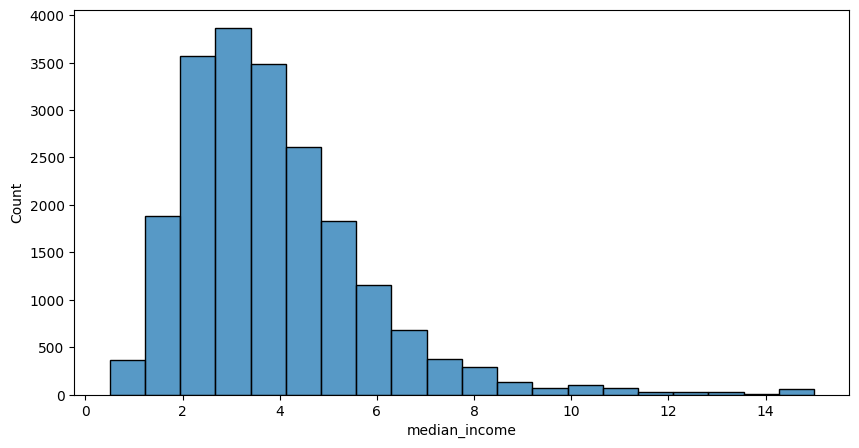

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_income'], bins = 20)
plt.show()

Tracons son boxplot pour détecter les valeurs extremes

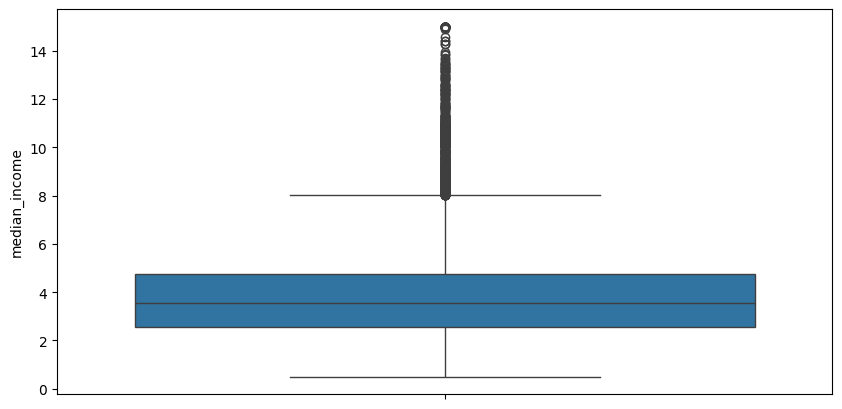

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(df['median_income'])
plt.show()

On voit clairement la présence des valeurs extremes, appliquons maintenant une transformation logarithmique à cette variable afin diminuer leur impact dans le modèle.

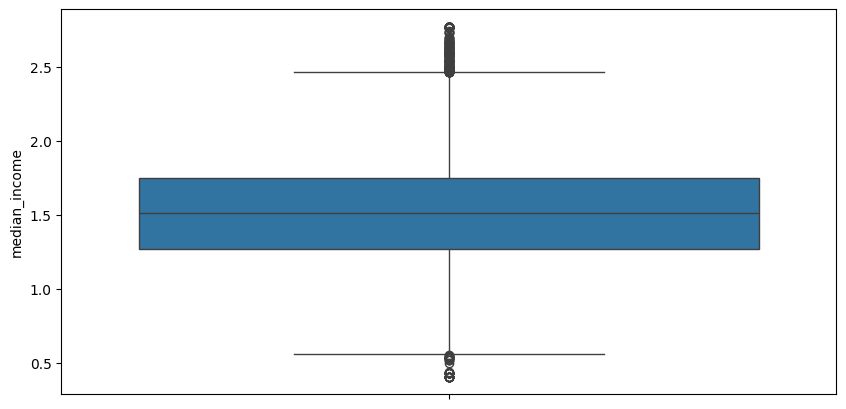

In [ ]:
df['median_income'] = np.log1p(df['median_income'])

plt.figure(figsize=(10, 5))
sns.boxplot(df['median_income'])
plt.show()

Analysons la variable Total roms

In [ ]:
stat_rooms = {
    'mean': df['total_rooms'].mean(),
    'median': df['total_rooms'].median(),
    'std': df['total_rooms'].std(),
    'min': df['total_rooms'].min(),
    'max': df['total_rooms'].max()

}

stat_rooms

{'mean': np.float64(2635.7630813953488),
 'median': 2127.0,
 'std': 2181.615251582787,
 'min': 2.0,
 'max': 39320.0}

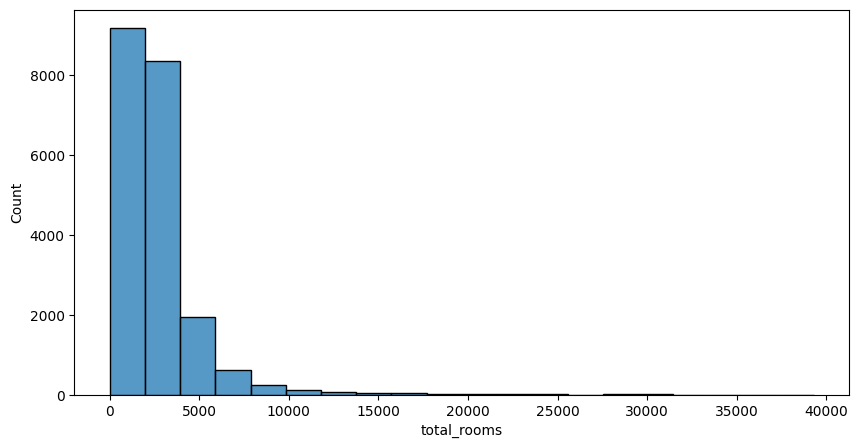

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_rooms'], bins = 20)
plt.show()

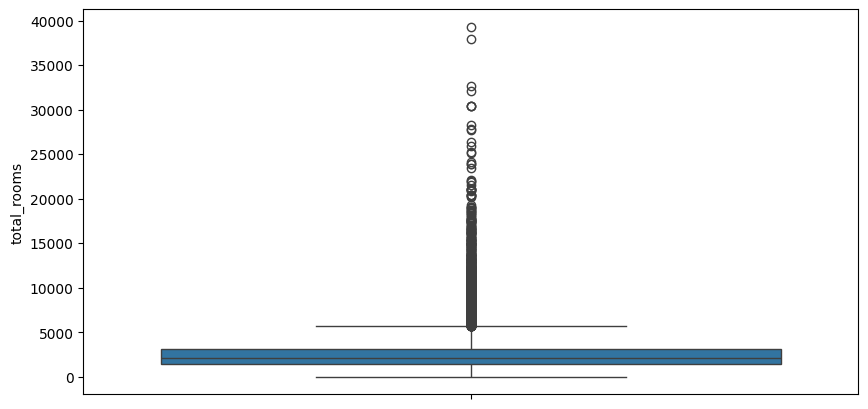

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(df['total_rooms'])
plt.show()

In [ ]:
df['total_rooms'] = np.log1p(df['total_rooms'])
df['total_rooms'] = np.exp(df['total_rooms'])

{
    'mean': df['total_rooms'].mean(),
    'median': df['total_rooms'].median(),
    'std': df['total_rooms'].std(),
}

{'mean': np.float64(2636.7630813953488),
 'median': 2128.0000000000005,
 'std': 2181.615251582787}

**II Data Preprocessing**

- Encoder les variables catégorielles
- Scaling pour les variables variables continues
- Data spliting : formation de l'échantillon d'apprentissage et de test

In [ ]:
## Encodage de la variable catégorielle
encoder = OneHotEncoder()
df_enc = encoder.fit_transform(df[['ocean_proximity']]).toarray()

df_enc = pd.DataFrame(df_enc, columns=encoder.get_feature_names_out(['ocean_proximity']))

In [ ]:
df_enc.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
df = df.drop(['ocean_proximity'], axis=1)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,881.0,129.0,322.0,126.0,2.232720,13.022766
1,-122.22,37.86,21.0,7100.0,1106.0,2401.0,1138.0,2.230165,12.789687
2,-122.24,37.85,52.0,1468.0,190.0,496.0,177.0,2.111110,12.771673
3,-122.25,37.85,52.0,1275.0,235.0,558.0,219.0,1.893579,12.740520
4,-122.25,37.85,52.0,1628.0,280.0,565.0,259.0,1.578195,12.743154


In [ ]:
df_geom = df[['longitude', 'latitude']]
df = df.drop(['longitude', 'latitude'], axis=1)

In [ ]:
df.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value'],
      dtype='object')

On sépare les prédicteur et la variable.

Les prédicteur stocké dans X sont l'ensemble des variable de notre échantillon sauf la variable cible noté y

In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [ ]:
X.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income'],
      dtype='object')

On la méthode de centrage et réduction sur les prédicteurs continues. Cette méthode conssiste à retrancer la moyenne de chaque observation de la variable et diviser le resultat obtenu par l'écart-type de cette varaiable

In [ ]:
scaler = StandardScaler()

df_scale = scaler.fit_transform(X)

In [ ]:
df_scale = pd.DataFrame(df_scale, columns=scaler.get_feature_names_out(X.columns))

In [ ]:
df_scale.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,1.995505
1,-0.607019,2.045890,1.357143,0.861439,1.669961,1.988380
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.656444
3,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,1.049948
4,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,0.170631


In [ ]:
X = pd.concat([df_scale, df_enc, df_geom], axis=1)
X.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,longitude,latitude
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,1.995505,0.0,0.0,0.0,1.0,0.0,-122.23,37.88
1,-0.607019,2.045890,1.357143,0.861439,1.669961,1.988380,0.0,0.0,0.0,1.0,0.0,-122.22,37.86
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.656444,0.0,0.0,0.0,1.0,0.0,-122.24,37.85
3,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,1.049948,0.0,0.0,0.0,1.0,0.0,-122.25,37.85
4,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,0.170631,0.0,0.0,0.0,1.0,0.0,-122.25,37.85


Division de notre échantillon en échantillon d'apprentissage et de teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=123)

**III Modélisation et Evaluation des modéles**

- Entrainement avec l'échantillon d'apprentissage
- Evalution avec l'échantillon de teste

In [ ]:
## Régression linéaire

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([12.35126624, 11.73603828, 12.0255868 , ..., 11.27884328,
       12.00592838, 12.61296043])

In [ ]:
## Evaluation du modele

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

metrics = {
    'mae': mae,
    'rmse': rmse,
    'r2': r2
}

metrics

{'mae': 0.23879551603876661,
 'rmse': np.float64(0.31656910411471256),
 'r2': 0.6867100814778719}

In [ ]:
# @title
np.exp(metrics['rmse'])

np.float64(1.3724110782119827)

In [ ]:
# Arbre de Décision

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_dt = dt.predict(X_test)
y_pred_dt

array([12.4415439 , 11.8988747 , 11.97980547, ..., 11.03651737,
       12.23077014, 12.99929364])

In [ ]:
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

metrics_dt = {
    'mae': mae,
    'rmse': rmse,
    'r2': r2
}

metrics_dt

{'mae': 0.2143843412903089,
 'rmse': np.float64(0.3156297918299914),
 'r2': 0.6885664880648794}

In [ ]:
## Forest aléatoire

rf = RandomForestRegressor(n_estimators= 200, max_depth= 8)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=200)

In [ ]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([12.28514495, 11.52545805, 12.07050433, ..., 11.27142379,
       12.15645144, 12.51271267])

In [ ]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

metrics_rf = {
    'mae': mae,
    'rmse': rmse,
    'r2': r2
}

metrics_rf

{'mae': 0.19403392899391653,
 'rmse': np.float64(0.26345663563205607),
 'r2': 0.7830160312078573}

**Troisième Partie: Regroupement**

- Utilisez un ensemble de données non étiquetées (par exemple, Iris sans étiquettes).
- Appliquez un algorithme de regroupement (par exemple, K-Means).
- Évaluer à l'aide de :

*Score de Silhouette Inertie Indice Rand ajusté (si les étiquettes vraies sont disponibles)

- Interpréter :

*Dans quelle mesure les grappes sont-elles bien séparées ?

*Qu'est-ce qui pourrait améliorer les résultats du regroupement ?

In [ ]:
# ===============================
# 1. Importation des librairies
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [ ]:
# ===============================
# 2. Chargement des données
# ===============================
iris = load_iris()
X = iris.data
y_true = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# ===============================
# 3. Prétraitement (standardisation)
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

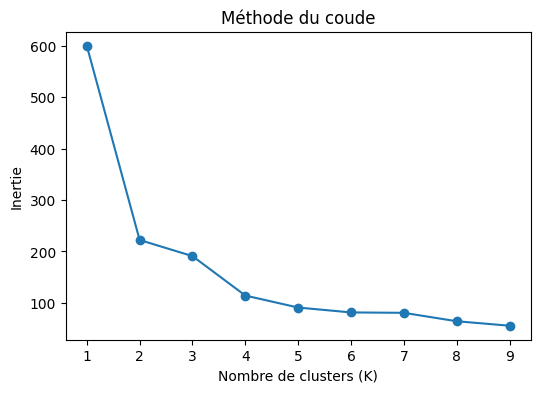

In [ ]:
# ===============================
# 4. Choix du nombre de clusters (méthode du coude)
# ===============================
inertia_list = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.show()

In [ ]:
# ===============================
# 5. Modèle K-means (K=3)
# ===============================
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels

In [ ]:
# ===============================
# 6. Évaluation
# ===============================
sil_score = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)
inertia = kmeans.inertia_

print("Silhouette Score :", sil_score)
print("Adjusted Rand Index :", ari)
print("Inertie :", inertia)

Silhouette Score : 0.5817500491982808
Adjusted Rand Index : 0.5681159420289855
Inertie : 222.36170496502302


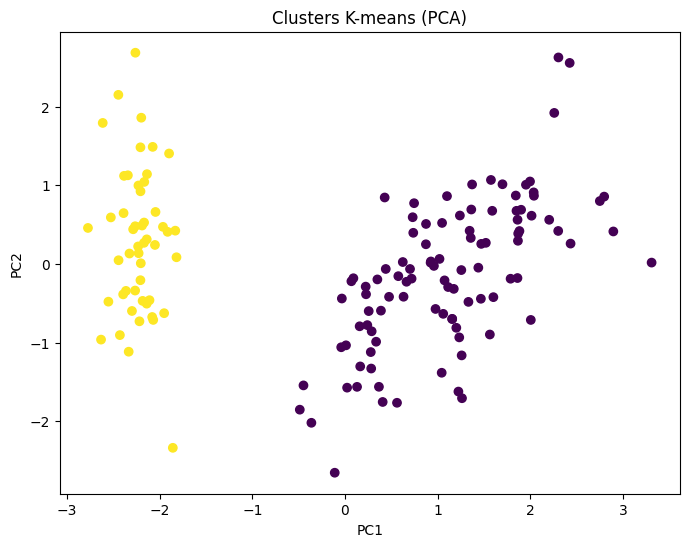

In [ ]:
# ===============================
# 7. Visualisation avec PCA
# ===============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters K-means (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# ===============================
# 8. Centres des clusters
# ===============================
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

df_centers = pd.DataFrame(centers_original, columns=iris.feature_names)
print("\nCentres des clusters :")
print(df_centers)


Centres des clusters :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0              6.262             2.872              4.906             1.676
1              5.006             3.428              1.462             0.246


In [ ]:
# ===============================
# 9. Profil des clusters
# ===============================
cluster_profile = df.groupby("cluster").mean()

print("\nProfil des clusters :")
print(cluster_profile)


Profil des clusters :
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
0                    6.262             2.872              4.906   
1                    5.006             3.428              1.462   

         petal width (cm)  
cluster                    
0                   1.676  
1                   0.246  


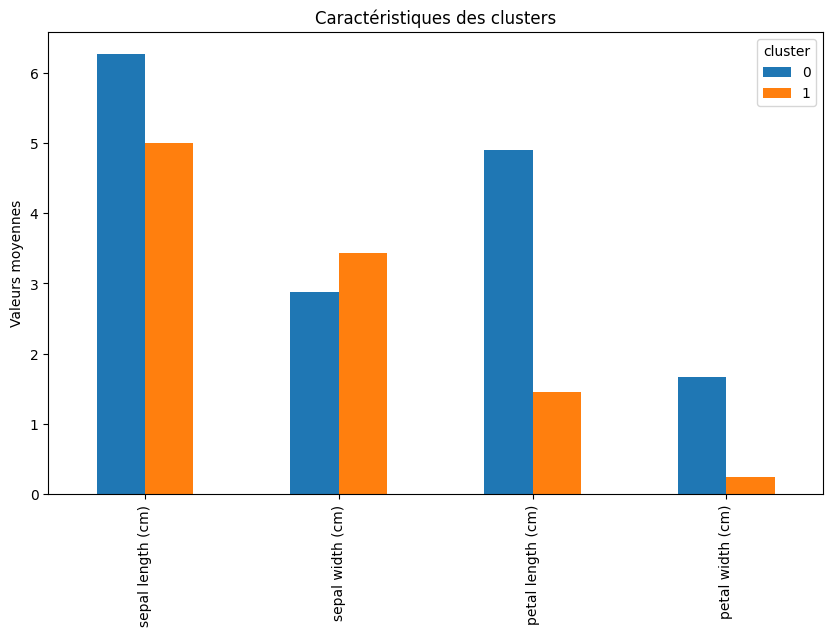

In [ ]:
# ===============================
# 10. Visualisation des caractéristiques
# ===============================
cluster_profile.T.plot(kind='bar', figsize=(10,6))
plt.title("Caractéristiques des clusters")
plt.ylabel("Valeurs moyennes")
plt.show()

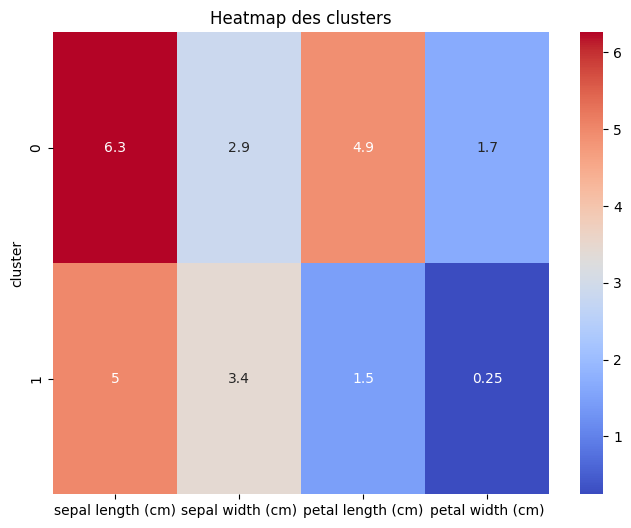

In [ ]:
# ===============================
# 11. Heatmap (analyse avancée)
# ===============================
plt.figure(figsize=(8,6))
sns.heatmap(cluster_profile, annot=True, cmap="coolwarm")
plt.title("Heatmap des clusters")
plt.show()